<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Марат! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

# Проект для "Викишоп" с BERT

## Описание проекта

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию.
Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.
Постройте модель со значением метрики качества **F1 не меньше 0.75**.

## Подключение библиотек

In [49]:
pip install transformers torch -q

In [50]:
pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com -q

In [51]:
import pandas as pd
import transformers
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm import notebook #отображение индикатора прогресса
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from cuml.svm import SVC as cumlSVC
from sklearn.metrics import f1_score, make_scorer

RANDOM_STATE = 42
pd.set_option('display.max_colwidth', None)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Но их лучше собрать в одной ячейке и разделить на функциональные группы пустой строкой.</font>

<span style="color: purple; font-weight: bold">Комментарий студента</span><br>
Исправил

## Подготовка данных

In [52]:
try:
    df = pd.read_csv('toxic_comments.csv')
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/toxic_comments.csv')

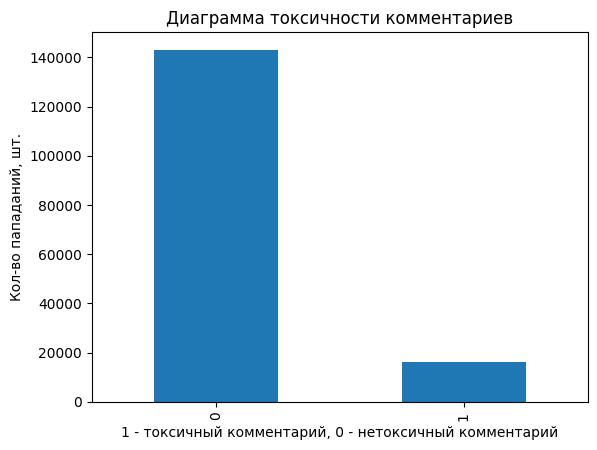

In [53]:
df['toxic'].value_counts().plot(kind='bar')
plt.title('Диаграмма токсичности комментариев')
plt.xlabel('1 - токсичный комментарий, 0 - нетоксичный комментарий')
plt.ylabel('Кол-во пападаний, шт.')
plt.show()

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Мы обнаружили серьёзный дисбаланс при исследовании данных. Как дополнительные материалы, рекомендую статью <a href='https://dyakonov.org/2021/05/27/imbalance/'>Дисбаланс классов</a>, очень классная, как и весь блог Дьяконова. Ещё такой <a href='https://github.com/Dyakonov/ml_hacks/blob/master/book_disbalance_public_v1.ipynb'>ноутбук</a> есть.</font>

Обнаружен дисбаланс, устраним его позже

Для ускорения создания эмбеддингов возьмем из выборки по 30000 случайных элементов

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> Мы не можем балансировать весь датасет, поскольку в этом случае мы балансируем также тестовую выборку. С такой тестовой выборкой метрика не сможет адекватно оценить работу модели на входящих данных с реальным распределением таргетов. </font>

<span style="color: purple; font-weight: bold">Комментарий студента</span><br>
Исправил. Согласно теории это можно сделать через ImbPipeline, он устраняет дисбаланс только у трейна, а валид не трогает

In [54]:
df = df.sample(30000, random_state=RANDOM_STATE).reset_index(drop=True)

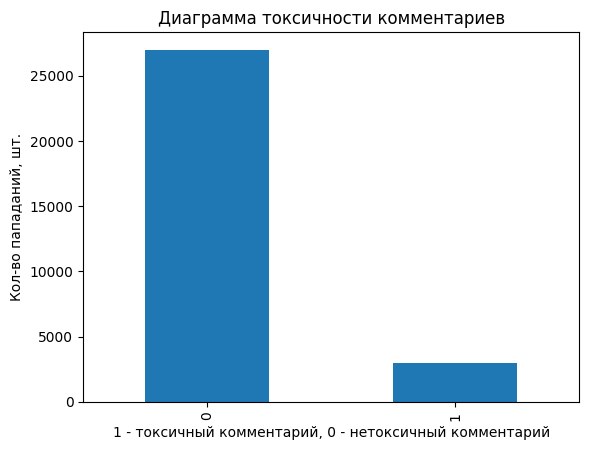

In [55]:
df['toxic'].value_counts().plot(kind='bar')
plt.title('Диаграмма токсичности комментариев')
plt.xlabel('1 - токсичный комментарий, 0 - нетоксичный комментарий')
plt.ylabel('Кол-во пападаний, шт.')
plt.show()

In [56]:
df.head(1)

,Unnamed: 0,text,toxic
0,31055,"Sometime back, I just happened to log on to www.izoom.in with a friend’s reference and I was amazed to see the concept Fresh Ideas Entertainment has come up with. So many deals… all under one roof. This website is very user friendly and easy to use and is fun to be on.\nYou have Gossip, Games, Facts… Another exciting feature to add to it is Face of the Week… Every week, 4 new faces are selected and put up as izoom faces. It’s great to have been selected in four out of a group of millions. \nThis new start up has already got many a deals in its kitty. Few of them being TheFortune Hotel, The Beach… are my personal favorites. izoom.in has a USP of mobile coupons. Coupons are available even when a user cannot access internet. You just need to SMS izoom support to 56767 and you get attended immediately.\nAll I can say is izoom.in is a must visit website for everyone before they go out for shopping or dining or for outing.\nCheers!!!",0


Комментарии на англ. языке, поэтому будем использовать BERT для англ. языка

In [57]:
df = df[['text', 'toxic']]

In [58]:
df.head(1)

,text,toxic
0,"Sometime back, I just happened to log on to www.izoom.in with a friend’s reference and I was amazed to see the concept Fresh Ideas Entertainment has come up with. So many deals… all under one roof. This website is very user friendly and easy to use and is fun to be on.\nYou have Gossip, Games, Facts… Another exciting feature to add to it is Face of the Week… Every week, 4 new faces are selected and put up as izoom faces. It’s great to have been selected in four out of a group of millions. \nThis new start up has already got many a deals in its kitty. Few of them being TheFortune Hotel, The Beach… are my personal favorites. izoom.in has a USP of mobile coupons. Coupons are available even when a user cannot access internet. You just need to SMS izoom support to 56767 and you get attended immediately.\nAll I can say is izoom.in is a must visit website for everyone before they go out for shopping or dining or for outing.\nCheers!!!",0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    30000 non-null  object
 1   toxic   30000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 468.9+ KB


In [60]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Для этой задачи существуют специальные модели, например 'unitary/toxic-bert'</font>

<span style="color: purple; font-weight: bold">Комментарий студента</span><br>
Но это готовый классификатор, а мне его использовать нельзя

In [61]:
tokenized = df['text'].apply(
    lambda x: tokenizer.encode(x, add_special_tokens=True, max_length=512, truncation=True)
)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Верно, что подрезаешь вектор токенов в Токенизаторе.</font>

In [62]:
tokenized.head(1).values

array([list([101, 8811, 2067, 1010, 1045, 2074, 3047, 2000, 8833, 2006, 2000, 7479, 1012, 1045, 23221, 2213, 1012, 1999, 2007, 1037, 2767, 1521, 1055, 4431, 1998, 1045, 2001, 15261, 2000, 2156, 1996, 4145, 4840, 4784, 4024, 2038, 2272, 2039, 2007, 1012, 2061, 2116, 9144, 1529, 2035, 2104, 2028, 4412, 1012, 2023, 4037, 2003, 2200, 5310, 5379, 1998, 3733, 2000, 2224, 1998, 2003, 4569, 2000, 2022, 2006, 1012, 2017, 2031, 13761, 1010, 2399, 1010, 8866, 1529, 2178, 10990, 3444, 2000, 5587, 2000, 2009, 2003, 2227, 1997, 1996, 2733, 1529, 2296, 2733, 1010, 1018, 2047, 5344, 2024, 3479, 1998, 2404, 2039, 2004, 1045, 23221, 2213, 5344, 1012, 2009, 1521, 1055, 2307, 2000, 2031, 2042, 3479, 1999, 2176, 2041, 1997, 1037, 2177, 1997, 8817, 1012, 2023, 2047, 2707, 2039, 2038, 2525, 2288, 2116, 1037, 9144, 1999, 2049, 14433, 1012, 2261, 1997, 2068, 2108, 1996, 13028, 9816, 3309, 1010, 1996, 3509, 1529, 2024, 2026, 3167, 20672, 1012, 1045, 23221, 2213, 1012, 1999, 2038, 1037, 2149, 2361, 1997, 4684, 8

In [63]:
max_len = 0
for i in tokenized.values:
    if max_len < len(i):
        max_len = len(i)
max_len

512

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<span style="color: darkorange"> Это лишнее.</span>

<span style="color: purple; font-weight: bold">Комментарий студента</span><br>
Это я проверяю алгоритмы для себя)

In [64]:
padded = np.array([i + [0] * (max_len - len(i)) for i in tokenized.values])

In [65]:
padded[0]

array([  101,  8811,  2067,  1010,  1045,  2074,  3047,  2000,  8833,
        2006,  2000,  7479,  1012,  1045, 23221,  2213,  1012,  1999,
        2007,  1037,  2767,  1521,  1055,  4431,  1998,  1045,  2001,
       15261,  2000,  2156,  1996,  4145,  4840,  4784,  4024,  2038,
        2272,  2039,  2007,  1012,  2061,  2116,  9144,  1529,  2035,
        2104,  2028,  4412,  1012,  2023,  4037,  2003,  2200,  5310,
        5379,  1998,  3733,  2000,  2224,  1998,  2003,  4569,  2000,
        2022,  2006,  1012,  2017,  2031, 13761,  1010,  2399,  1010,
        8866,  1529,  2178, 10990,  3444,  2000,  5587,  2000,  2009,
        2003,  2227,  1997,  1996,  2733,  1529,  2296,  2733,  1010,
        1018,  2047,  5344,  2024,  3479,  1998,  2404,  2039,  2004,
        1045, 23221,  2213,  5344,  1012,  2009,  1521,  1055,  2307,
        2000,  2031,  2042,  3479,  1999,  2176,  2041,  1997,  1037,
        2177,  1997,  8817,  1012,  2023,  2047,  2707,  2039,  2038,
        2525,  2288,

In [66]:
len(padded[0])

512

In [67]:
attention_mask = np.where(padded != 0, 1, 0)

In [68]:
attention_mask[0]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [69]:
try:
  model = transformers.BertModel.from_pretrained('pytorch_model.bin')
except:
  model = transformers.BertModel.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [70]:
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda', index=0)

In [71]:
model.to(device)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [72]:
batch_size = 100
embeddings = []

for i in notebook.tqdm(range(padded.shape[0] // batch_size)):
    batch = torch.LongTensor(padded[batch_size * i : batch_size * (i + 1)]).to(device)
    attention_mask_batch = torch.LongTensor(attention_mask[batch_size * i : batch_size * (i + 1)]).to(device)

    with torch.no_grad():
        batch_embeddings = model(batch, attention_mask=attention_mask_batch)

    embeddings.append(batch_embeddings[0][:,0,:].cpu().numpy())
    del batch
    del attention_mask_batch
    del batch_embeddings

  0%|          | 0/300 [00:00<?, ?it/s]

<font color='green'>
Если, обучать BERT на GPU (можно в Google Colab или Kaggle), то должно быть побыстрее.

<font color='green'>Пример BERT с GPU:
```python
%%time
from tqdm import notebook
batch_size = 2 # для примера возьмем такой батч, где будет всего две строки датасета
embeddings = []
model.cuda()   # закидываем модель на GPU
for i in notebook.tqdm(range(input_ids.shape[0] // batch_size)):
        batch = torch.LongTensor(input_ids[batch_size*i:batch_size*(i+1)]).cuda() # закидываем тензор на GPU
        attention_mask_batch = torch.LongTensor(attention_mask[batch_size*i:batch_size*(i+1)]).cuda()

        with torch.no_grad():
            batch_embeddings = model(batch, attention_mask=attention_mask_batch)

        embeddings.append(batch_embeddings[0][:,0,:].cpu().numpy()) # перевод обратно на проц, чтобы в нумпай кинуть
        del batch
        del attention_mask_batch
        del batch_embeddings

features = np.concatenate(embeddings)
```
НО нужно сделать предварительную проверку на наличие GPU.\
Например, так: ```device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")```\
Тогда вместо .cuda() нужно писать .to(device)

</font>

In [73]:
features = np.concatenate(embeddings)

In [74]:
features.shape

(30000, 768)

## Построение предсказательных моделей

In [75]:
X_train, X_test, y_train, y_test = train_test_split(features, df['toxic'], random_state=RANDOM_STATE, stratify=df['toxic'])

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Здорово, что у нас есть выборка для тестов!</font>

In [76]:
pipe_final = ImbPipeline(
    [
        ('rUS', RandomUnderSampler(random_state=RANDOM_STATE)),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [77]:
param_grid = [
    #{
    #    'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)]
    #},
    #
    #{
    #    'models': [LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)]
    #},

    {
        'models': [cumlSVC(random_state=RANDOM_STATE)],
        'models__kernel': ['rbf', 'linear', 'poly'],
        'models__degree': range(3, 5)
    }
]

In [78]:
grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    n_jobs=-1,
    scoring='f1'
)

In [79]:
grid_search.fit(X_train, y_train)

GridSearchCV(estimator=Pipeline(steps=[('rUS',
                                        RandomUnderSampler(random_state=42)),
                                       ('models',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'models': [SVC()], 'models__degree': range(3, 5),
                          'models__kernel': ['rbf', 'linear', 'poly']}],
             scoring='f1')

In [80]:
pd.DataFrame(grid_search.cv_results_)[['rank_test_score', 'mean_test_score','params']]

,rank_test_score,mean_test_score,params
0,3,0.602005,"{'models': SVC(), 'models__degree': 3, 'models__kernel': 'rbf'}"
1,5,0.552069,"{'models': SVC(), 'models__degree': 3, 'models__kernel': 'linear'}"
2,1,0.606633,"{'models': SVC(), 'models__degree': 3, 'models__kernel': 'poly'}"
3,3,0.602005,"{'models': SVC(), 'models__degree': 4, 'models__kernel': 'rbf'}"
4,5,0.552069,"{'models': SVC(), 'models__degree': 4, 'models__kernel': 'linear'}"
5,2,0.606343,"{'models': SVC(), 'models__degree': 4, 'models__kernel': 'poly'}"


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично, что есть табличка результатов для сравнения.</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> Нужно показать все параметры в поле `params` для анализа.
```python
# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)
```
И можно ограничиться полями ['rank_test_score', 'mean_test_score','params']</font>

In [81]:
f1_best = grid_search.best_score_

In [82]:
print('Среднее значение метрики F1 на валидационной выборке', f1_best)

Среднее значение метрики F1 на валидационной выборке 0.6066325594344425


In [83]:
f1_test = f1_score(y_test, grid_search.predict(X_test))

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Тестирование проведено верно.</font>

In [85]:
print('Среднее значение метрики F1 на тестовой выборке', f1_test)

Среднее значение метрики F1 на тестовой выборке 0.6165137614678899


## Вывод

Среднее значение метрики F1 на валидационной выборке на модели BERT составляет 0.6, что не удовлетворяет требованию Заказчика. Для улучшения значения метрики были испробованы различные методики устранения дисбаланса, но они не дали результата. Возможно увеличение значения метрики за счет увеличения размера датафрейма, что невозможно в связи с техническими ограничениями, или переход на другую языковую модель, что нарушает условия задачи.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Очень приятно видеть вывод в конце проекта! В выводах можно приводить полученные ранее значения. Также можно расписать все, что было сделано в ходе проведения работы. Представь, что тебе заплатят исходя из объёма сделанных тобой выводов )).</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Марат, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
</font>

<font color='blue'>Что нужно исправить:</font>
<ul><font color='red'>Не балансируй тестовые и валидационные данные.</font></ul>

<font color='blue'>Что можно сделать лучше:</font>
<font color='orange'>В работе я оставил несколько советов. Буду рад, если ты учтешь их.</font></ul>

<font color='blue'><b>Жду новую версию проекта :)</b></font>